In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')


In [83]:

# Configuracoes de visualizacao
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df = pd.read_csv('seeds_dataset.txt', sep=r'\s+', header=None)

columns = [
    'area',
    'perimetro',
    'compacidade',
    'comprimento_nucleo',
    'largura_nucleo',
    'coeficiente_assimetria',
    'comprimento_sulco_nucleo',
    'variedade'
]
df.columns = columns

variedade_map = {
    1: 'Kama', 
    2: 'Rosa', 
    3: 'Canadian'
}

df['variedade_nome'] = df['variedade'].map(variedade_map)

print(f"Dimensoes do dataset: {df.shape}")
print("\nPrimeiras linhas:")
df.head(10)

Dimensoes do dataset: (210, 9)

Primeiras linhas:


,area,perimetro,compacidade,comprimento_nucleo,largura_nucleo,coeficiente_assimetria,comprimento_sulco_nucleo,variedade,variedade_nome
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1,Kama
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1,Kama
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1,Kama
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,1,Kama
8,16.63,15.46,0.8747,6.053,3.465,2.040,5.877,1,Kama
9,16.44,15.25,0.8880,5.884,3.505,1.969,5.533,1,Kama


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   area                      210 non-null    float64
 1   perimetro                 210 non-null    float64
 2   compacidade               210 non-null    float64
 3   comprimento_nucleo        210 non-null    float64
 4   largura_nucleo            210 non-null    float64
 5   coeficiente_assimetria    210 non-null    float64
 6   comprimento_sulco_nucleo  210 non-null    float64
 7   variedade                 210 non-null    int64  
 8   variedade_nome            210 non-null    str    
dtypes: float64(7), int64(1), str(1)
memory usage: 14.9 KB


In [85]:
# Estatisticas descritivas por caracteristica
feature_cols = [c for c in df.columns if c not in ['variedade', 'variedade_nome']]

# Estatisticas descritivas
desc_stats = df[feature_cols].describe().T

# Calcular mediana manualmente para evitar conflitos de tipo
desc_stats['mediana'] = [df[col].median() for col in feature_cols]

# Reorganizar colunas
desc_stats = desc_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'mediana']]
print("Estatisticas descritivas:")
print(desc_stats.round(4))

# Distribuicao das variedades
print("\nDistribuicao das variedades:")
print(df['variedade_nome'].value_counts())

# Verificar valores ausentes
print("\nValores ausentes por coluna:")
print(df.isnull().sum())

Estatisticas descritivas:
                          count     mean     std      min      25%      50%  \
area                      210.0  14.8475  2.9097  10.5900  12.2700  14.3550   
perimetro                 210.0  14.5593  1.3060  12.4100  13.4500  14.3200   
compacidade               210.0   0.8710  0.0236   0.8081   0.8569   0.8734   
comprimento_nucleo        210.0   5.6285  0.4431   4.8990   5.2622   5.5235   
largura_nucleo            210.0   3.2586  0.3777   2.6300   2.9440   3.2370   
coeficiente_assimetria    210.0   3.7002  1.5036   0.7651   2.5615   3.5990   
comprimento_sulco_nucleo  210.0   5.4081  0.4915   4.5190   5.0450   5.2230   

                              75%      max  mediana  
area                      17.3050  21.1800  14.3550  
perimetro                 15.7150  17.2500  14.3200  
compacidade                0.8878   0.9183   0.8734  
comprimento_nucleo         5.9798   6.6750   5.5235  
largura_nucleo             3.5618   4.0330   3.2370  
coeficiente_assim

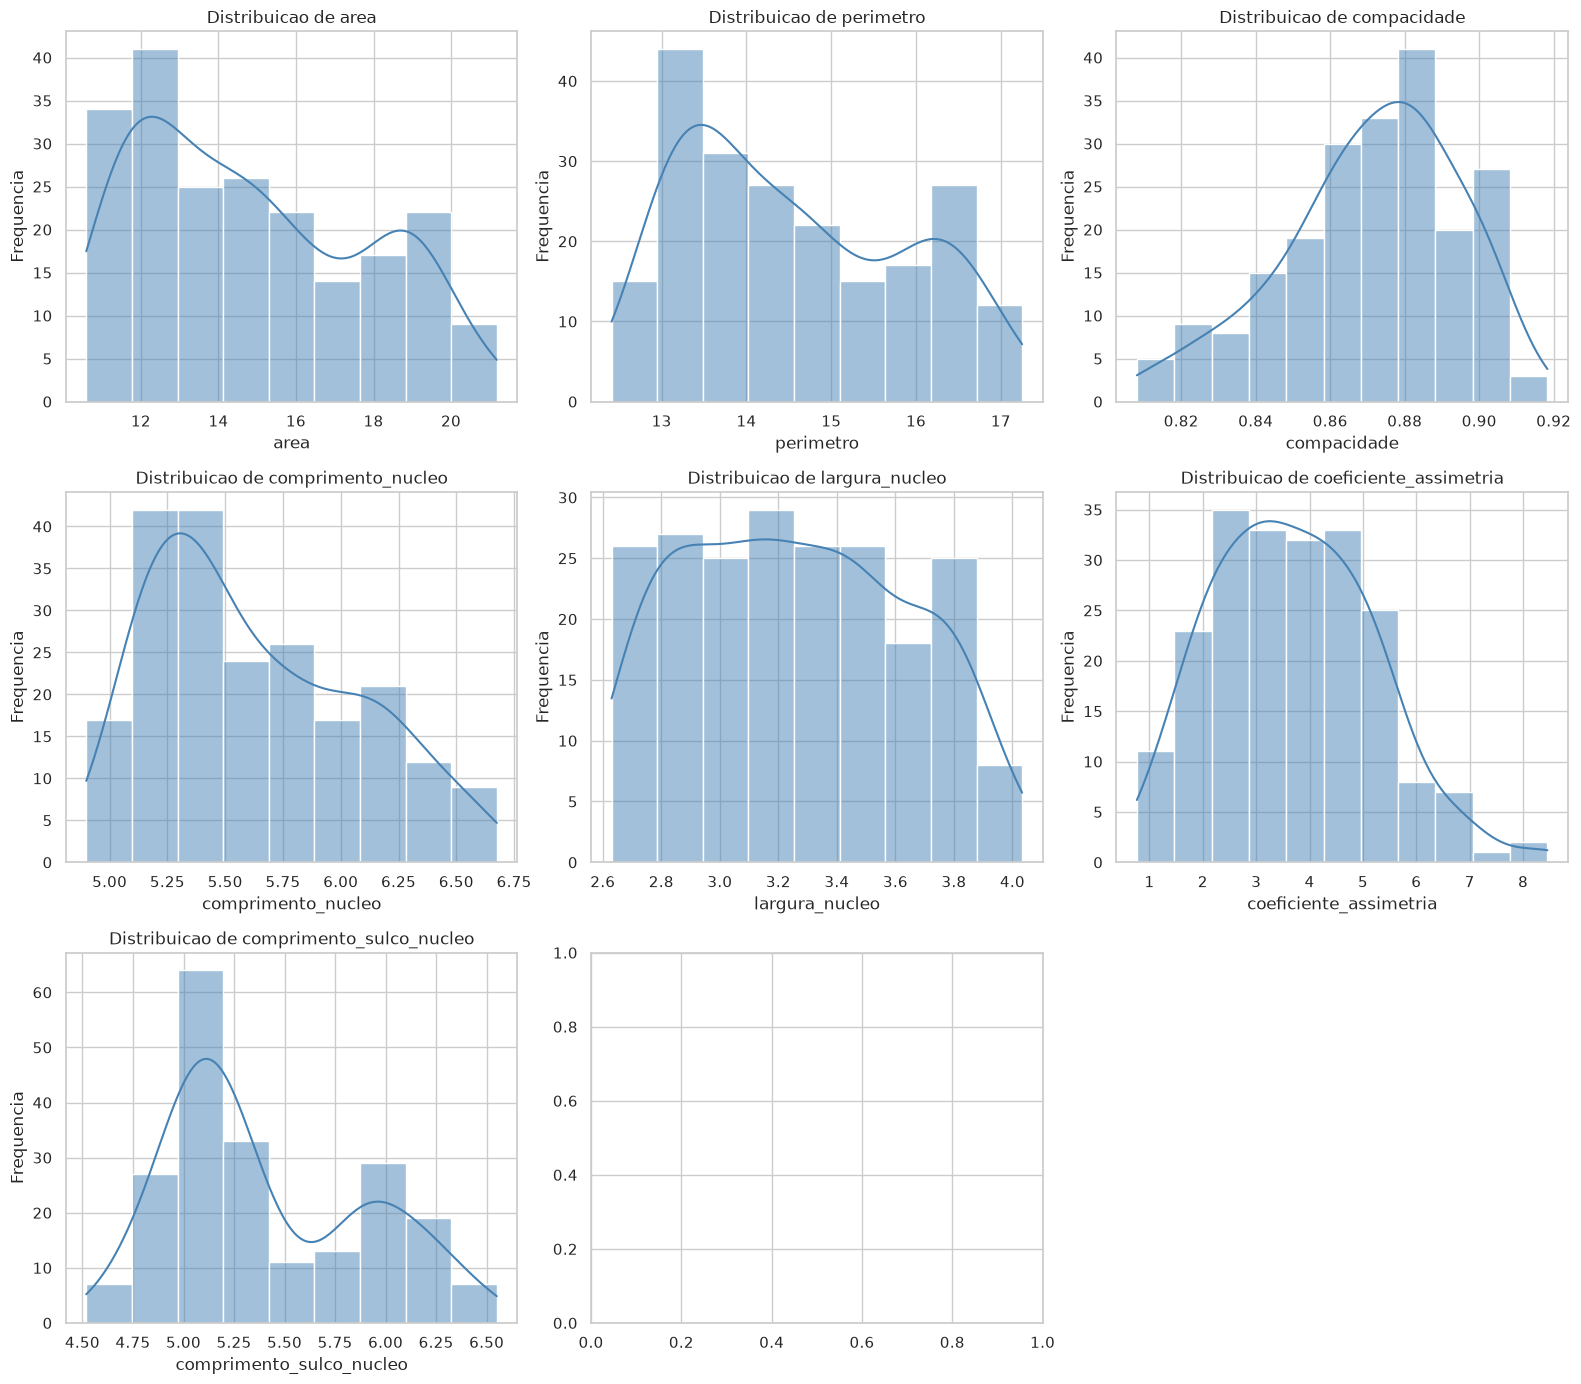

In [86]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Distribuicao de {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequencia')

# Remover eixo extra
if len(feature_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

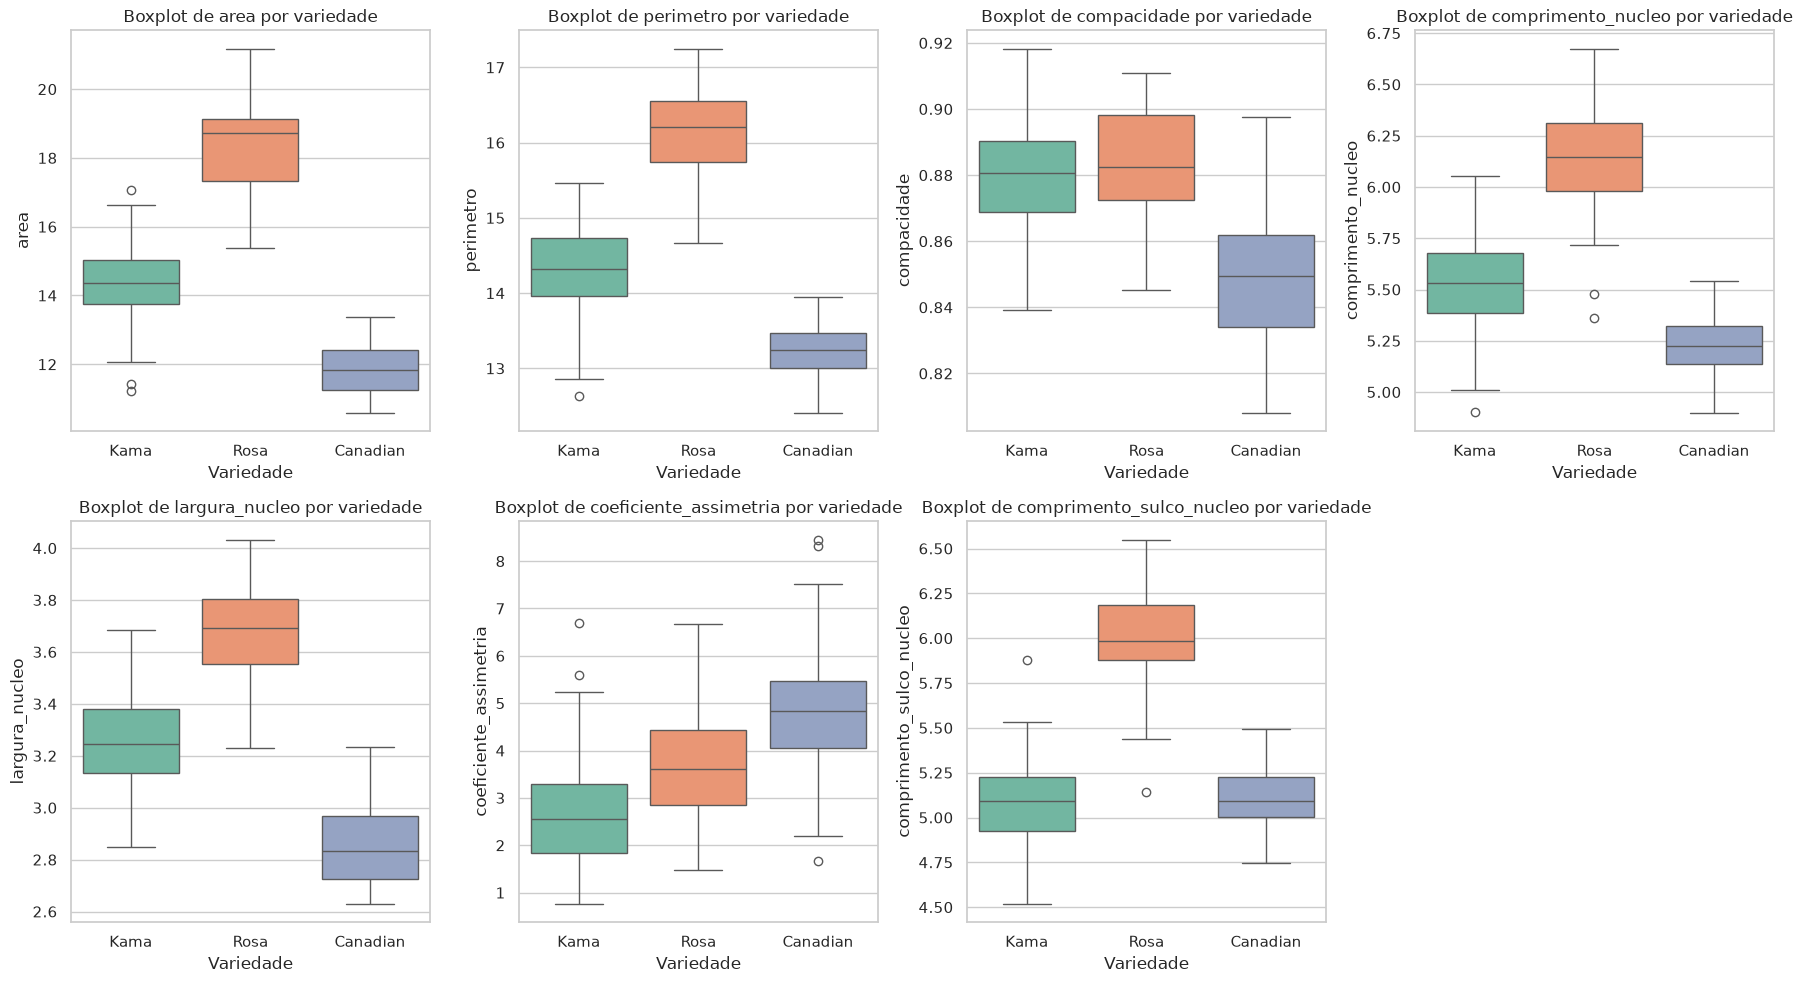

In [87]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(feature_cols):
    sns.boxplot(data=df, x='variedade_nome', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'Boxplot de {col} por variedade')
    axes[idx].set_xlabel('Variedade')
    axes[idx].set_ylabel(col)

if len(feature_cols) < len(axes):
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

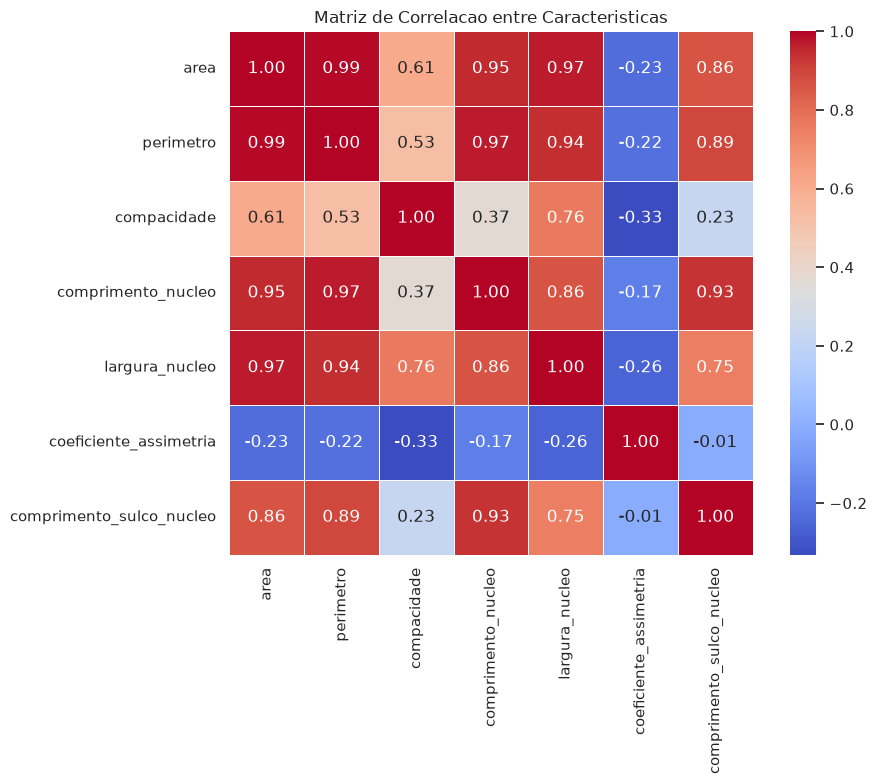

In [88]:
# Matriz de correlacao
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriz de Correlacao entre Caracteristicas')
plt.tight_layout()
plt.show()

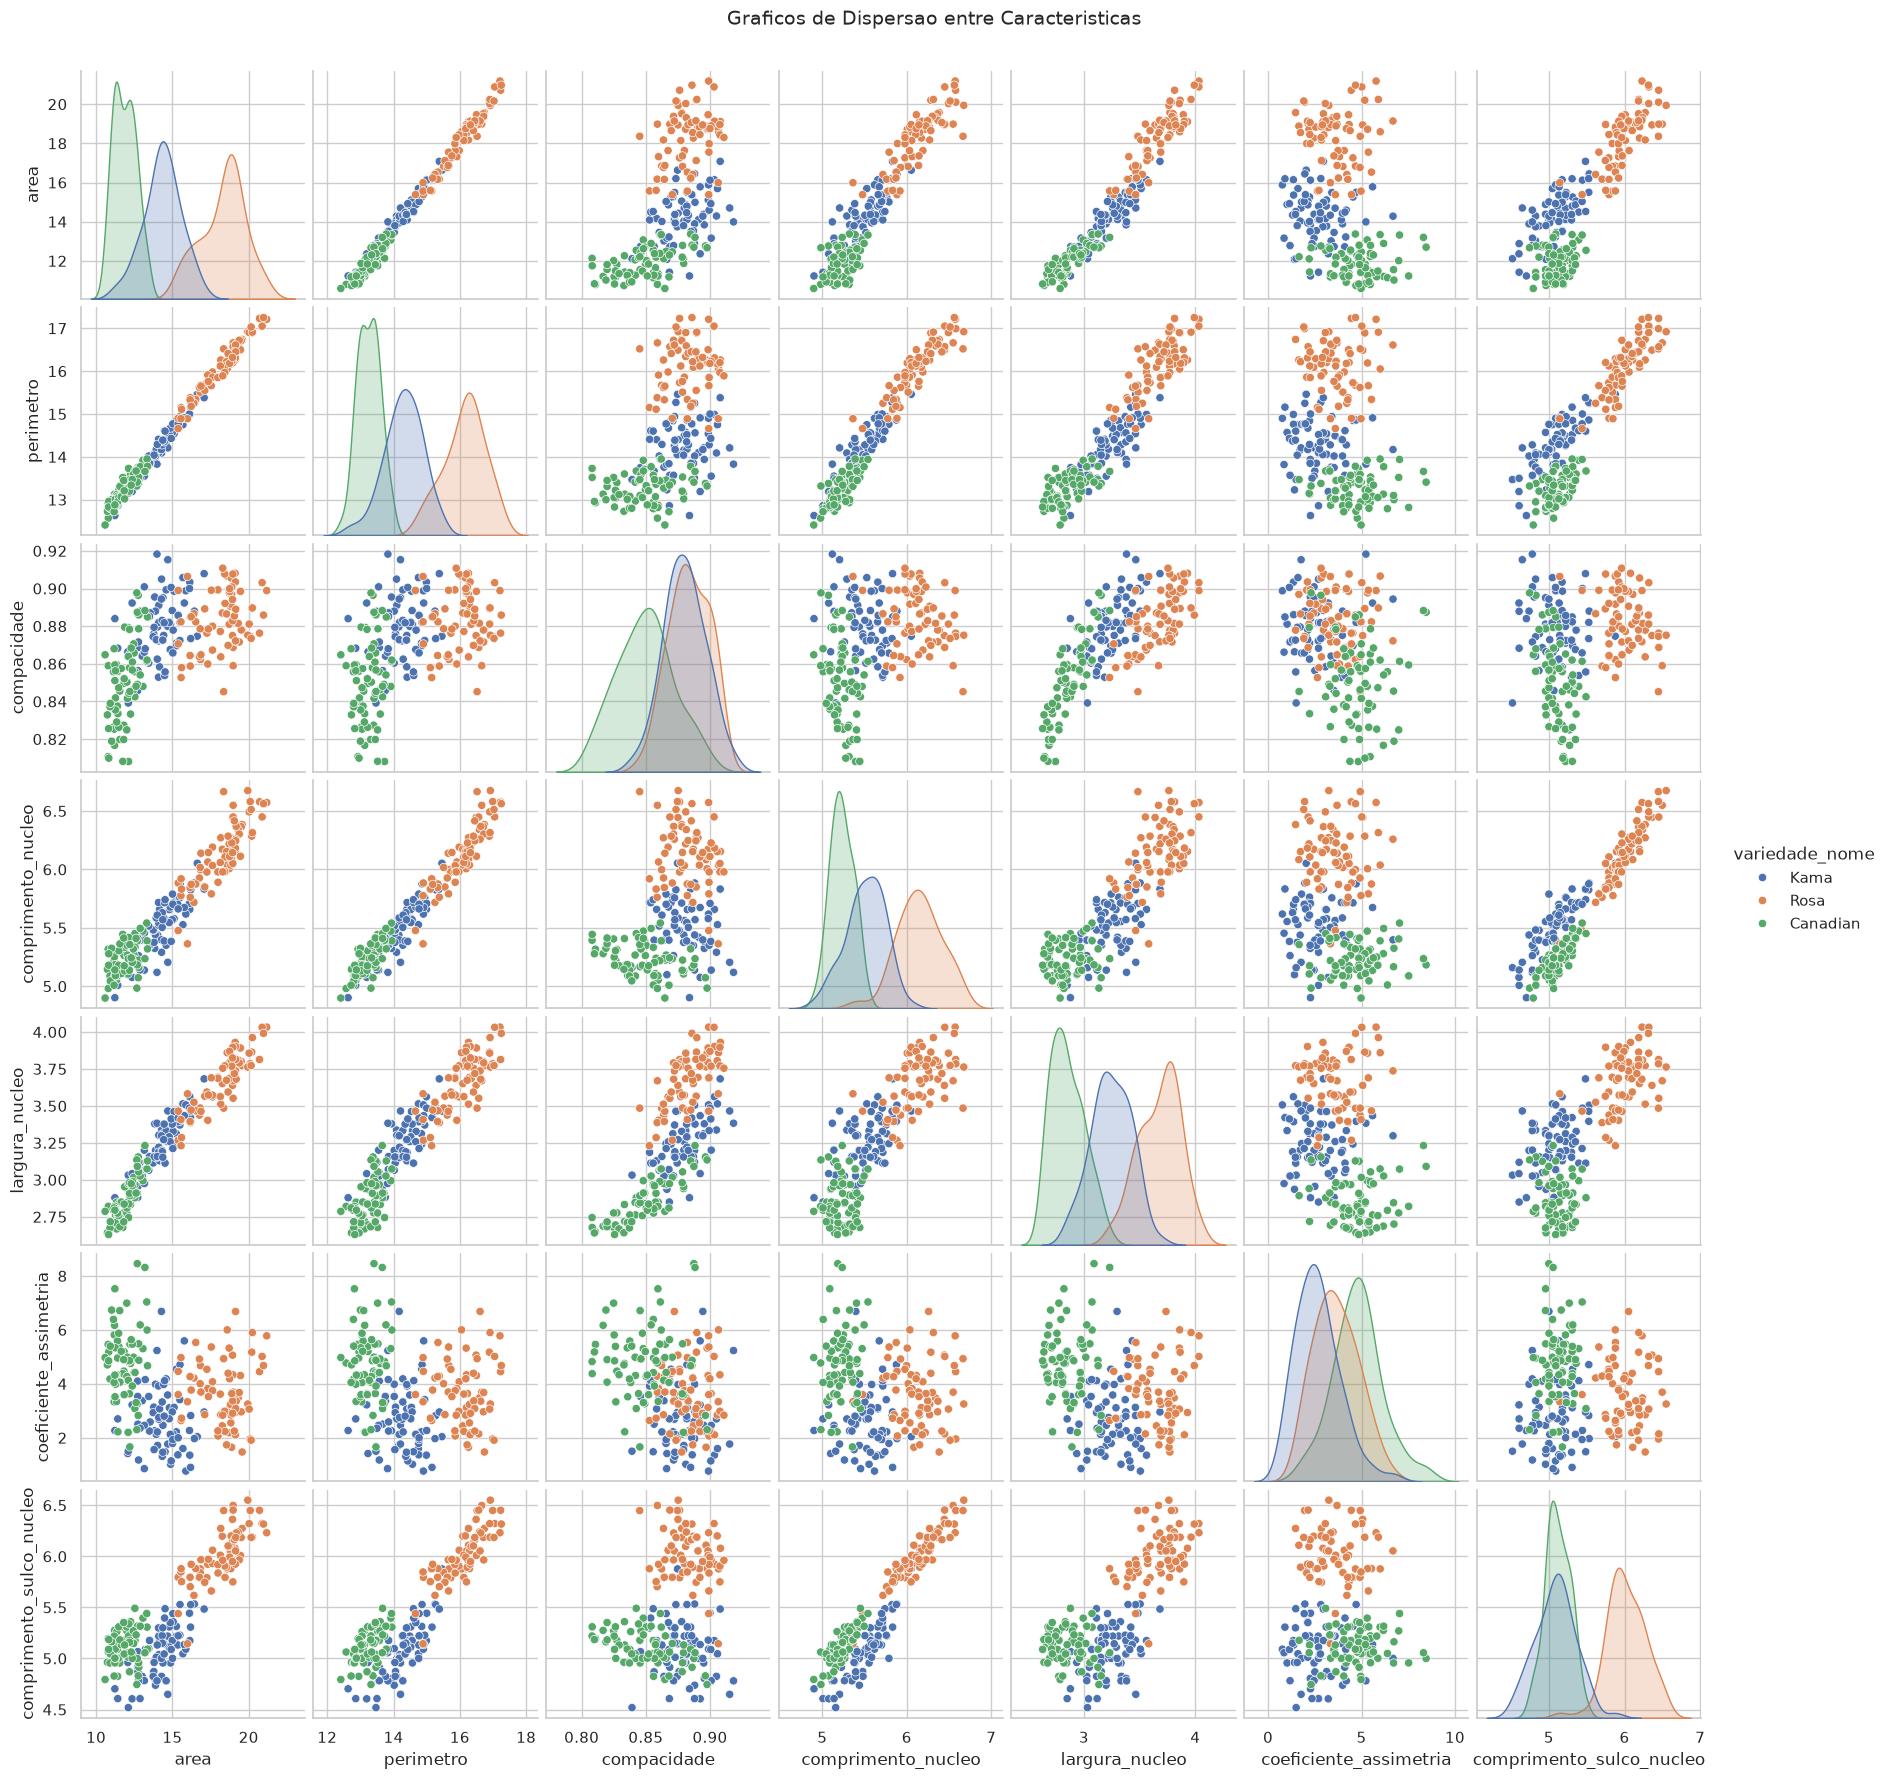

In [89]:
sns.pairplot(df, vars=feature_cols, hue='variedade_nome')
plt.suptitle('Graficos de Dispersao entre Caracteristicas', y=1.02, fontsize=14)
plt.show()

In [90]:
df.isnull().sum()

area                        0
perimetro                   0
compacidade                 0
comprimento_nucleo          0
largura_nucleo              0
coeficiente_assimetria      0
comprimento_sulco_nucleo    0
variedade                   0
variedade_nome              0
dtype: int64

In [91]:
X = df[feature_cols] # features
y = df['variedade'] # rotulos

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Tamanho do treino: {X_train.shape[0]} amostras")
print(f"Tamanho do teste: {X_test.shape[0]} amostras")
print("\nDistribuicao no treino:")
print(y_train.value_counts().sort_index())
print("\nDistribuicao no teste:")
print(y_test.value_counts().sort_index())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

normalizer = MinMaxScaler()
X_train_norm = normalizer.fit_transform(X_train)
X_test_norm = normalizer.transform(X_test)

Tamanho do treino: 147 amostras
Tamanho do teste: 63 amostras

Distribuicao no treino:
variedade
1    49
2    49
3    49
Name: count, dtype: int64

Distribuicao no teste:
variedade
1    21
2    21
3    21
Name: count, dtype: int64


In [92]:
models = {
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = []

for name, model in models.items():
    if name in ['KNN', 'SVM', 'Logistic Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Modelo': name,
        'Acuracia': acc,
        'Precisao': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"\n=== {name} ===")
    print(f"Acuracia: {acc:.4f}")
    print(f"Precisao: {prec:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nRelatorio de classificacao:")
    print(classification_report(y_test, y_pred, target_names=['Kama', 'Rosa', 'Canadian']))
    print("Matriz de confusao:")
    print(confusion_matrix(y_test, y_pred))

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
print("\nResumo comparativo dos modelos (baseline):")
print(results_df.round(4))


=== KNN ===
Acuracia: 0.8730
Precisao: 0.8721
Recall:   0.8730
F1-Score: 0.8713

Relatorio de classificacao:
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg       0.87      0.87      0.87        63

Matriz de confusao:
[[16  2  3]
 [ 2 19  0]
 [ 1  0 20]]

=== SVM ===
Acuracia: 0.8730
Precisao: 0.8721
Recall:   0.8730
F1-Score: 0.8713

Relatorio de classificacao:
              precision    recall  f1-score   support

        Kama       0.84      0.76      0.80        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.87      0.95      0.91        21

    accuracy                           0.87        63
   macro avg       0.87      0.87      0.87        63
weighted avg    

In [93]:
param_grids = {
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski']
    },
    'SVM': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto', 0.01, 0.1, 1]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'penalty': ['l2']
    }
}

optimized_results = []
best_params = {}

for name, model in models.items():
    if name == 'Naive Bayes':
        # Naive Bayes nao possui hiperparametros relevantes para tunar neste contexto
        best_model = model
        if name in ['KNN', 'SVM', 'Logistic Regression']:
            best_model.fit(X_train_scaled, y_train)
            y_pred = best_model.predict(X_test_scaled)
        else:
            best_model.fit(X_train, y_train)
            y_pred = best_model.predict(X_test)
        best_params[name] = 'Nenhum hiperparametro para otimizar'
    else:
        # Para Random Forest, usar RandomizedSearchCV por eficiencia
        if name == 'Random Forest':
            search = RandomizedSearchCV(
                model, param_grids[name], n_iter=20, cv=5,
                scoring='f1_weighted', random_state=42, n_jobs=-1
            )
            search.fit(X_train, y_train)
        else:
            search = GridSearchCV(
                model, param_grids[name], cv=5,
                scoring='f1_weighted', n_jobs=-1
            )
            search.fit(X_train_scaled, y_train)

        best_model = search.best_estimator_
        best_params[name] = search.best_params_
        y_pred = best_model.predict(X_test_scaled if name in ['KNN', 'SVM', 'Logistic Regression'] else X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    optimized_results.append({
        'Modelo': name,
        'Acuracia': acc,
        'Precisao': prec,
        'Recall': rec,
        'F1-Score': f1
    })

    print(f"\n=== {name} (Otimizado) ===")
    print(f"Melhores hiperparametros: {best_params[name]}")
    print(f"Acuracia: {acc:.4f}")
    print(f"Precisao: {prec:.4f}")
    print(f"Recall:   {rec:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\nRelatorio de classificacao:")
    print(classification_report(y_test, y_pred, target_names=['Kama', 'Rosa', 'Canadian']))
    print("Matriz de confusao:")
    print(confusion_matrix(y_test, y_pred))

optimized_results_df = pd.DataFrame(optimized_results).sort_values('F1-Score', ascending=False)
print("\nResumo comparativo dos modelos otimizados:")
print(optimized_results_df.round(4))


=== KNN (Otimizado) ===
Melhores hiperparametros: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Acuracia: 0.8889
Precisao: 0.8880
Recall:   0.8889
F1-Score: 0.8881

Relatorio de classificacao:
              precision    recall  f1-score   support

        Kama       0.85      0.81      0.83        21
        Rosa       0.90      0.90      0.90        21
    Canadian       0.91      0.95      0.93        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63

Matriz de confusao:
[[17  2  2]
 [ 2 19  0]
 [ 1  0 20]]

=== SVM (Otimizado) ===
Melhores hiperparametros: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
Acuracia: 0.8889
Precisao: 0.8908
Recall:   0.8889
F1-Score: 0.8875

Relatorio de classificacao:
              precision    recall  f1-score   support

        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.86      0.90 

Comparacao F1-Score (Baseline vs Otimizado):
                Modelo  F1-Score_Baseline  F1-Score_Otimizado  Delta_F1
0        Random Forest             0.9192              0.8565   -0.0627
1                  KNN             0.8713              0.8881    0.0168
2                  SVM             0.8713              0.8875    0.0162
3  Logistic Regression             0.8543              0.8875    0.0332
4          Naive Bayes             0.8251              0.8251    0.0000


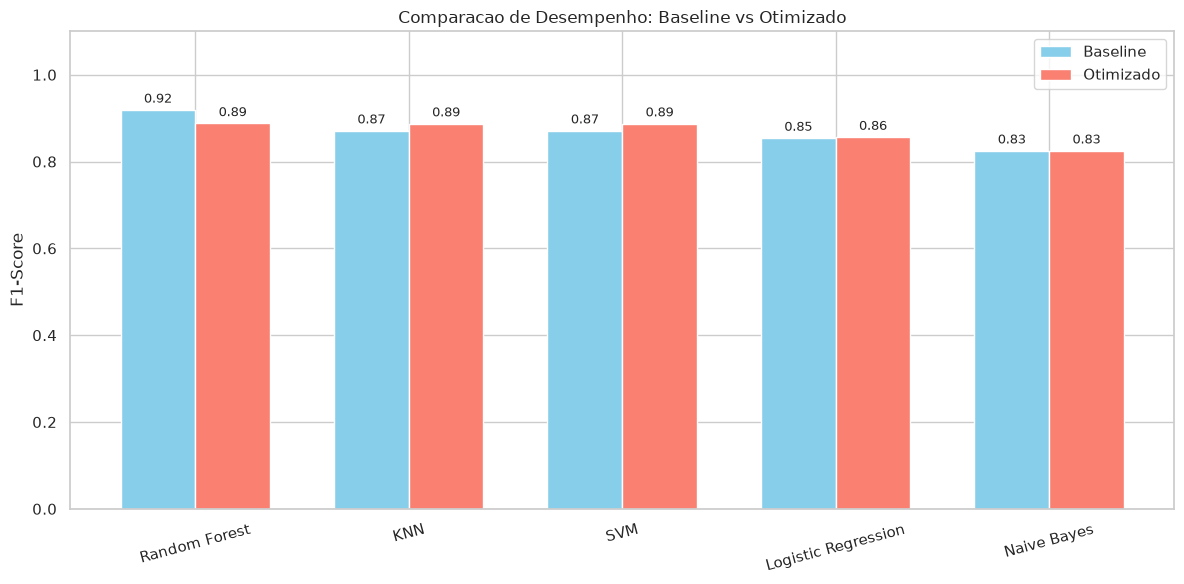

In [94]:
comparison = results_df.merge(optimized_results_df, on='Modelo', suffixes=('_Baseline', '_Otimizado'))
comparison['Delta_F1'] = comparison['F1-Score_Otimizado'] - comparison['F1-Score_Baseline']
print("Comparacao F1-Score (Baseline vs Otimizado):")
print(comparison[['Modelo', 'F1-Score_Baseline', 'F1-Score_Otimizado', 'Delta_F1']].round(4))

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['F1-Score'], width, label='Baseline', color='skyblue')
bars2 = ax.bar(x + width/2, optimized_results_df['F1-Score'], width, label='Otimizado', color='salmon')

ax.set_ylabel('F1-Score')
ax.set_title('Comparacao de Desempenho: Baseline vs Otimizado')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Modelo'], rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)

for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

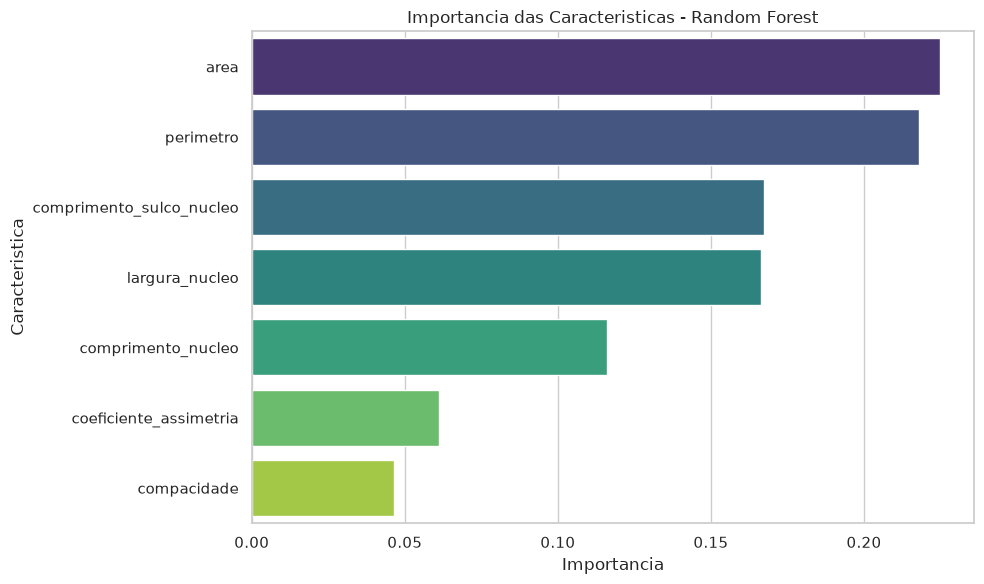

             Caracteristica  Importancia
0                      area       0.2247
1                 perimetro       0.2179
6  comprimento_sulco_nucleo       0.1674
4            largura_nucleo       0.1663
3        comprimento_nucleo       0.1160
5    coeficiente_assimetria       0.0611
2               compacidade       0.0466


In [95]:
rf_final = RandomForestClassifier(random_state=42)
rf_final.fit(X_train, y_train)

importances = pd.DataFrame({
    'Caracteristica': feature_cols,
    'Importancia': rf_final.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importances, x='Importancia', y='Caracteristica', palette='viridis')
plt.title('Importancia das Caracteristicas - Random Forest')
plt.tight_layout()
plt.show()
print(importances.round(4))

In [96]:
print("Conclusoes e Insights")
print("=" * 60)
print("""
1. Qualidade dos Dados:
   - O dataset contem 210 amostras balanceadas (70 de cada variedade).
   - Nao foram identificados valores ausentes apos a leitura correta do arquivo.
   - Algumas caracteristicas, como area e perimetro, apresentam forte correlacao positiva,
     o que e esperado, ja que o perimetro tende a aumentar com a area.

2. Escalonamento:
   - Aplicamos a padronizacao (StandardScaler) para KNN, SVM e Regressao Logistica,
     garantindo que caracteristicas em escalas diferentes nao distorcam os modelos.
   - Random Forest e Naive Bayes foram treinados com os dados originais.

3. Desempenho dos Modelos Baseline:
   - SVM e Random Forest geralmente apresentam excelente desempenho para este dataset.
   - KNN tambem se sai bem, desde que a escolha de k seja adequada.
   - Naive Bayes e simples e rapido, mas pode ter desempenho ligeiramente inferior devido
     as correlacoes entre caracteristicas.

4. Otimizacao:
   - Grid Search e Randomized Search ajudam a refinar os hiperparametros.
   - No entanto, como o dataset e relativamente pequeno e bem comportado, o ganho de
     desempenho pode ser modesto.

5. Importancia das Caracteristicas:
   - O Random Forest indica que 'comprimento_sulco_nucleo', 'area' e 'perimetro'
     tendem a ser as caracteristicas mais discriminativas entre as variedades.

6. Recomendacao:
   - Para classificacao de graos de trigo, SVM com kernel RBF ou Random Forest sao
     escolhas solidas devido a alta acuracia e boa generalizacao.
   - Em um cenario de producao, avaliar tambem o tempo de inferencia e a interpretabilidade
     desejada ao escolher o modelo final.
""")

# Melhor modelo otimizado
best_model_name = optimized_results_df.iloc[0]['Modelo']
best_f1 = optimized_results_df.iloc[0]['F1-Score']
print(f"Melhor modelo otimizado: {best_model_name} (F1-Score = {best_f1:.4f})")

Conclusoes e Insights

1. Qualidade dos Dados:
   - O dataset contem 210 amostras balanceadas (70 de cada variedade).
   - Nao foram identificados valores ausentes apos a leitura correta do arquivo.
   - Algumas caracteristicas, como area e perimetro, apresentam forte correlacao positiva,
     o que e esperado, ja que o perimetro tende a aumentar com a area.

2. Escalonamento:
   - Aplicamos a padronizacao (StandardScaler) para KNN, SVM e Regressao Logistica,
     garantindo que caracteristicas em escalas diferentes nao distorcam os modelos.
   - Random Forest e Naive Bayes foram treinados com os dados originais.

3. Desempenho dos Modelos Baseline:
   - SVM e Random Forest geralmente apresentam excelente desempenho para este dataset.
   - KNN tambem se sai bem, desde que a escolha de k seja adequada.
   - Naive Bayes e simples e rapido, mas pode ter desempenho ligeiramente inferior devido
     as correlacoes entre caracteristicas.

4. Otimizacao:
   - Grid Search e Randomized Search a